In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"]=(12,6)
sns.set_style("whitegrid")

In [2]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

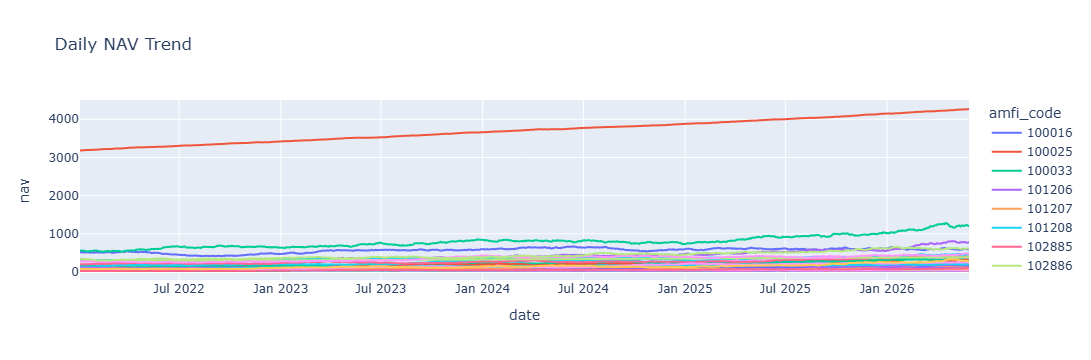

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend"
)

fig.show()

fig.write_image(
    "../charts/nav_trend.png"
)

In [10]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [12]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

print(aum[["date", "year"]].head())

        date  year
0 2022-03-31  2022
1 2022-03-31  2022
2 2022-03-31  2022
3 2022-03-31  2022
4 2022-03-31  2022


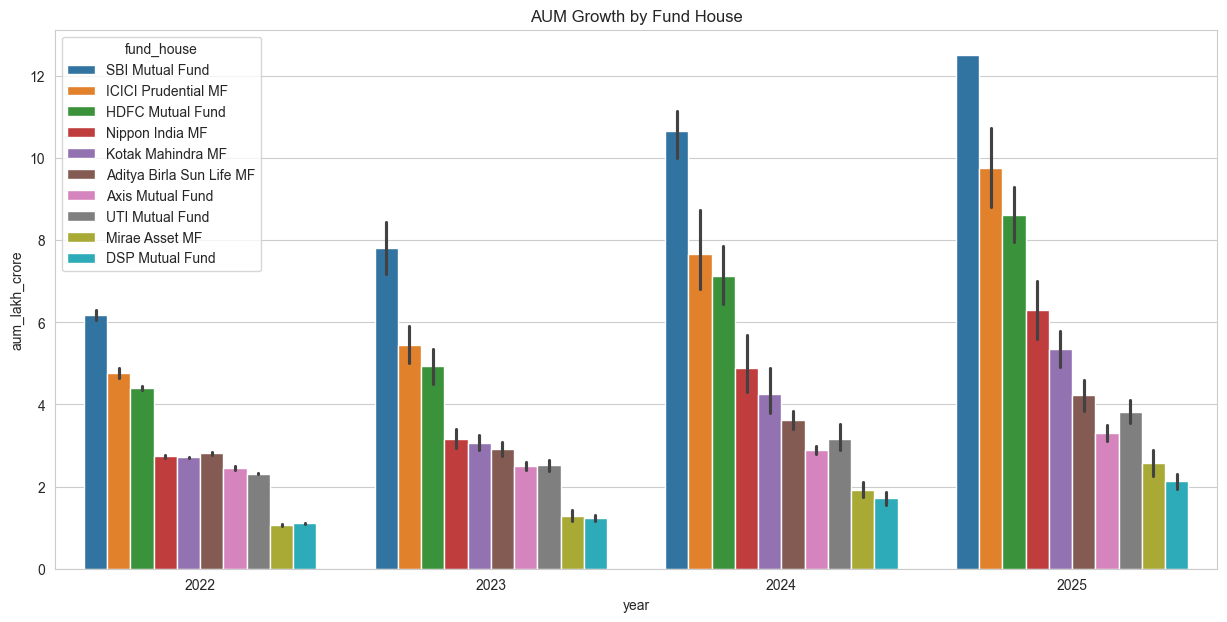

In [13]:
plt.figure(figsize=(15,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.savefig(
    "../charts/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [15]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")
    ["nav"]
    .pct_change()
)

In [16]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


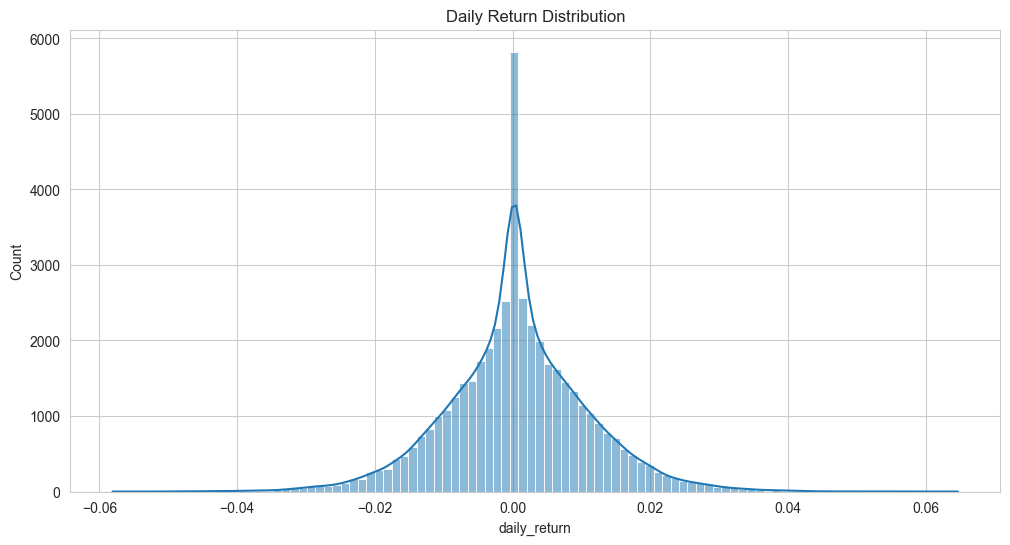

In [17]:
plt.figure(figsize=(12,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title(
    "Daily Return Distribution"
)

plt.savefig(
    "../charts/daily_return_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [18]:
cagr_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"]==code
    ]

    start_nav = temp.iloc[0]["nav"]

    end_nav = temp.iloc[-1]["nav"]

    years = (
        temp["date"].max()
        -
        temp["date"].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)
        **(1/years)
    ) - 1

    cagr_results.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [22]:
rf = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    returns = (
        nav[
            nav["amfi_code"]==code
        ]["daily_return"]
        .dropna()
    )

    annual_return = (
        returns.mean()*252
    )

    annual_std = (
        returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return-rf
    ) / annual_std

    sharpe_results.append(
        [code,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

In [23]:
sortino_results = []

for code in nav["amfi_code"].unique():

    returns = (
        nav[
            nav["amfi_code"]==code
        ]["daily_return"]
        .dropna()
    )

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean()*252
    )

    sortino = (
        annual_return-rf
    ) / downside_std

    sortino_results.append(
        [code,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [24]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [1]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [3]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

In [4]:
print(nav.shape)
print(benchmark.shape)

(46000, 3)
(8050, 3)


In [5]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print(benchmark.head())

        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15


In [6]:
print(
    benchmark["index_name"]
    .unique()
)

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [7]:
nifty100 = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

print(nifty100.head())

           date index_name  close_value
1150 2022-01-03   NIFTY100     17778.24
1151 2022-01-04   NIFTY100     17537.52
1152 2022-01-05   NIFTY100     17607.73
1153 2022-01-06   NIFTY100     17556.05
1154 2022-01-07   NIFTY100     17664.02


In [8]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [9]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [10]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [11]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [12]:
print(
    nav["daily_return"]
    .describe()
)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [13]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][["date", "daily_return"]]

    ...

In [14]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [15]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [16]:
from scipy.stats import linregress

alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    if len(merged) > 10:

        slope, intercept, r, p, std = (
            linregress(
                merged["benchmark_return"],
                merged["daily_return"]
            )
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [17]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [18]:
dd_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    running_max = (
        temp["nav"]
        .cummax()
    )

    drawdown = (
        temp["nav"]
        /
        running_max
    ) - 1

    dd_results.append(
        [
            code,
            drawdown.min()
        ]
    )

dd_df = pd.DataFrame(
    dd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [19]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [20]:
scorecard = (
    performance
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        dd_df,
        on="amfi_code"
    )
)

NameError: name 'sharpe_df' is not defined

In [21]:
rf = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    returns = (
        nav[
            nav["amfi_code"] == code
        ]["daily_return"]
        .dropna()
    )

    annual_return = returns.mean() * 252

    annual_std = (
        returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_std

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

print(sharpe_df.head())

   amfi_code  sharpe_ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661


In [22]:
print(alpha_beta_df.shape)
print(dd_df.shape)
print(sharpe_df.shape)

(40, 3)
(40, 2)
(40, 2)


In [23]:
scorecard = (
    performance
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        dd_df,
        on="amfi_code"
    )
)

print(scorecard.shape)

(40, 23)


In [24]:
scorecard["score"] = (

      scorecard["return_3yr_pct"]
      .rank(pct=True) * 30

    + scorecard["sharpe_ratio"]
      .rank(pct=True) * 25

    + scorecard["alpha"]
      .rank(pct=True) * 20

    + scorecard["expense_ratio_pct"]
      .rank(
          ascending=False,
          pct=True
      ) * 15

    + scorecard["max_drawdown"]
      .rank(
          ascending=False,
          pct=True
      ) * 10
)

KeyError: 'sharpe_ratio'

In [25]:
print(scorecard.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha_x', 'beta_x', 'sharpe_ratio_x', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'sharpe_ratio_y', 'alpha_y', 'beta_y', 'max_drawdown']


In [27]:
scorecard["score"] = (

      scorecard["return_3yr_pct"]
      .rank(pct=True) * 30

    + scorecard["sharpe_ratio_y"]
      .rank(pct=True) * 25

    + scorecard["alpha_y"]
      .rank(pct=True) * 20

    + scorecard["expense_ratio_pct"]
      .rank(
          ascending=False,
          pct=True
      ) * 15

    + scorecard["max_drawdown"]
      .rank(
          ascending=False,
          pct=True
      ) * 10
)

In [28]:
top_funds = (
    scorecard
    .sort_values(
        "score",
        ascending=False
    )
)

top_funds[
    [
        "amfi_code",
        "scheme_name",
        "score"
    ]
].head(10)

,amfi_code,scheme_name,score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,83.3750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,77.9375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,75.2500
26,119094,Axis Midcap Fund - Regular - Growth,70.2500
38,149323,DSP Midcap Fund - Regular - Growth,69.0000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,68.7500
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,63.0000
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,62.6875


In [29]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [30]:
scorecard = scorecard.rename(
    columns={
        "alpha_y": "alpha_calc",
        "beta_y": "beta_calc",
        "sharpe_ratio_y": "sharpe_calc"
    }
)

In [31]:
scorecard["sharpe_calc"]
scorecard["alpha_calc"]

0     0.232010
1     0.198686
2     0.303370
3     0.048824
4     0.056209
5     0.037476
6     0.177298
7     0.271954
8     0.119891
9     0.042818
10    0.177033
11    0.211948
12    0.292636
13    0.162539
14    0.067462
15    0.218294
16    0.156438
17    0.175007
18    0.151364
19    0.050748
20    0.130429
21    0.078044
22    0.273305
23    0.064557
24    0.068995
25    0.082328
26    0.260767
27    0.048016
28    0.213998
29    0.108971
30    0.060861
31    0.170488
32    0.028969
33    0.162113
34    0.269838
35    0.208730
36    0.282704
37    0.131732
38    0.265986
39    0.300579
Name: alpha_calc, dtype: float64

In [32]:
scorecard["score"] = (

      scorecard["return_3yr_pct"]
      .rank(pct=True) * 30

    + scorecard["sharpe_calc"]
      .rank(pct=True) * 25

    + scorecard["alpha_calc"]
      .rank(pct=True) * 20

    + scorecard["expense_ratio_pct"]
      .rank(
          ascending=False,
          pct=True
      ) * 15

    + scorecard["max_drawdown"]
      .rank(
          ascending=False,
          pct=True
      ) * 10
)

In [33]:
top_funds = (
    scorecard
    .sort_values(
        "score",
        ascending=False
    )
)

top_funds[
    [
        "scheme_name",
        "score"
    ]
].head(10)

,scheme_name,score
2,SBI Small Cap Fund - Regular Plan - Growth,83.3750
12,ICICI Pru Midcap Fund - Regular - Growth,82.2500
39,DSP Small Cap Fund - Regular - Growth,77.9375
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,76.0000
22,Kotak Flexicap Fund - Regular - Growth,75.2500
26,Axis Midcap Fund - Regular - Growth,70.2500
38,DSP Midcap Fund - Regular - Growth,69.0000
34,Mirae Asset Large Cap Fund - Regular - Growth,68.7500
11,ICICI Pru Bluechip Fund - Direct - Growth,63.0000
36,Mirae Asset Tax Saver Fund - Regular - Growth,62.6875


In [34]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [35]:
top5 = (
    scorecard
    .sort_values(
        "score",
        ascending=False
    )
    .head(5)
)

top5["amfi_code"]

2     119598
12    120505
39    149324
7     100033
22    120843
Name: amfi_code, dtype: int64

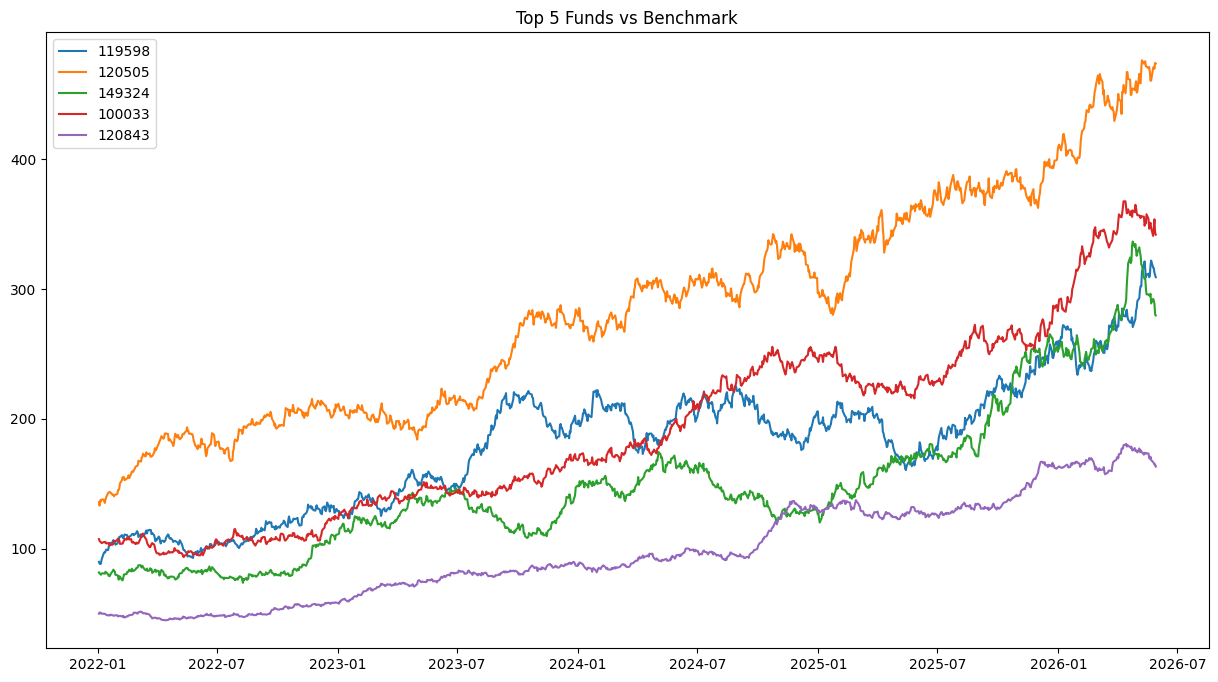

In [36]:
plt.figure(figsize=(15,8))

for code in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.legend()

plt.savefig(
    "../charts/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [37]:
tracking_error = []

for code in top5["amfi_code"]:

    fund = nav[
        nav["amfi_code"] == code
    ][["date","daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    te = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    tracking_error.append(
        [code, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,119598,0.283881
1,120505,0.231968
2,149324,0.279170
3,100033,0.228699
4,120843,0.206425


In [38]:
import os

print(
    os.path.exists(
        "../data/processed/fund_scorecard.csv"
    )
)

print(
    os.path.exists(
        "../data/processed/alpha_beta.csv"
    )
)

print(
    os.path.exists(
        "../charts/benchmark_comparison.png"
    )
)

True
True
True
